### Goals of this Phase
1. Build the NCF model architecture (Embeddings + MLP)
2. Train the model with appropriate parameters and configurations
3. Evaluate on the test set (RMSE, MAE)
4. Save the best model for later usage 

---
<!-- 
### 🧠 Why Neural Collaborative Filtering (NCF)?

Recall from the lecture: **Collaborative Filtering** predicts a user's rating for an
item based on patterns from other users/items (no need for item metadata).

Classic CF uses similarity formulas (Cosine, Pearson, etc.) directly on the
utility matrix. **NCF replaces the similarity formula with a neural network**:

- Each user and each movie gets a learned **embedding vector** (dense representation)
- User embedding + Movie embedding are combined and passed through
  a **Multi-Layer Perceptron (MLP)**
- The MLP learns **non-linear interactions** between users and movies —
  something classic similarity metrics (Cosine, Pearson) cannot capture
- Output: a predicted rating for that (user, movie) pair -->


# 1. Imports

In [48]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pre-defining configuration variables

In [49]:
SEED = 42
PROCESSED_DIR = 'processed'
MODEL_DIR = 'models'
DEVICE = 'cpu'
BATCH_SIZE = 256
EMBEDDING_DIM = 32
MLP_LAYERS = [64, 32, 32, 16]
N_EPOCHS = 30
PATIENCE = 10
BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'ncf_best_checkpoint.pt')

## 2. Setup

In [50]:


# setting the random seed beforehand for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)


# we're training on the cpu because the data is very small and 
# any model considered medium or large would result in instant overfitting


os.makedirs(MODEL_DIR, exist_ok=True)


## 3. Loading Processed Data

In [51]:
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train.csv'))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'val.csv'))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'test.csv'))

with open(os.path.join(PROCESSED_DIR, 'mappings.pkl'), 'rb') as f:
    mappings = pickle.load(f)

n_users = mappings['n_users']
n_movies = mappings['n_movies']

print("Train:", train_df.shape)
print("Val:", val_df.shape) 
print("Test:", test_df.shape)
print("n_users:", n_users)
print("n_movies:", n_movies)


Train: (80419, 6)
Val: (10059, 6)
Test: (10358, 6)
n_users: 610
n_movies: 9724


In [52]:
train_df.head()

,userId,movieId,rating,timestamp,user_idx,movie_idx
0,1,1031,5.0,964982653,0,55
1,1,4006,4.0,964982903,0,230
2,1,1197,5.0,964981872,0,69
3,1,2596,5.0,964981144,0,168
4,1,1777,4.0,964981230,0,109


## 4. Creating the  Dataset Class & the DataLoader

In [53]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = df['user_idx'].values.astype(np.int64)
        self.movies = df['movie_idx'].values.astype(np.int64)
        self.ratings = df['rating'].values.astype(np.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]



train_dataset = RatingsDataset(train_df)
val_dataset = RatingsDataset(val_df)
test_dataset = RatingsDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 315
Val batches: 40
Test batches: 41


## 5. NCF Model Architecture



<!-- ![model architecture](model_archi.png) -->
<img src="model_archi.png" width="1300" height="1000">


In [54]:
class NCF(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=32, mlp_layers=[64, 32, 16]):
        super(NCF, self).__init__()

        # Embeddings for the MLP branch
        self.user_embedding_mlp = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding_mlp = nn.Embedding(n_movies, embedding_dim)

        # Embeddings for the Matrix-Factorization (dot product) branch
        self.user_embedding_mf = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding_mf = nn.Embedding(n_movies, embedding_dim)

        # MLP layers
        mlp_modules = []
        input_size = embedding_dim * 2
        for layer_size in mlp_layers:
            mlp_modules.append(nn.Linear(input_size, layer_size))
            mlp_modules.append(nn.ReLU())
            mlp_modules.append(nn.Dropout(0.2))
            input_size = layer_size
        self.mlp = nn.Sequential(*mlp_modules)

        # Final layer: combines MF branch output (1 value) + MLP branch output
        self.output_layer = nn.Linear(mlp_layers[-1] + embedding_dim, 1)

        self._init_weights()

    def _init_weights(self):
        for emb in [self.user_embedding_mlp, self.movie_embedding_mlp,
                    self.user_embedding_mf, self.movie_embedding_mf]:
            nn.init.normal_(emb.weight, std=0.01)

    def forward(self, user_idx, movie_idx):
        # MF branch (element-wise product, like classic Matrix Factorization)
        user_mf = self.user_embedding_mf(user_idx)
        movie_mf = self.movie_embedding_mf(movie_idx)
        mf_vector = user_mf * movie_mf  # element-wise product

        # MLP branch
        user_mlp = self.user_embedding_mlp(user_idx)
        movie_mlp = self.movie_embedding_mlp(movie_idx)
        mlp_input = torch.cat([user_mlp, movie_mlp], dim=-1)
        mlp_vector = self.mlp(mlp_input)

        # Combine both branches
        combined = torch.cat([mlp_vector, mf_vector], dim=-1)
        output = self.output_layer(combined)

        return output.squeeze()


In [55]:
model = NCF(n_users, n_movies, embedding_dim=EMBEDDING_DIM, mlp_layers=MLP_LAYERS).to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")


NCF(
  (user_embedding_mlp): Embedding(610, 32)
  (movie_embedding_mlp): Embedding(9724, 32)
  (user_embedding_mf): Embedding(610, 32)
  (movie_embedding_mf): Embedding(9724, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=16, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
  )
  (output_layer): Linear(in_features=48, out_features=1, bias=True)
)

Total trainable parameters: 669,249


## 6. Training Setup
### **Training Configurations**
- **Loss function:** Mean Squared Error (MSE) — since we're predicting a continuous rating
- **Optimizer:** Adam, since it's used almost everywhere
- **Early Stopping:** the model almost immediately overfits, so we use early stopping to avoid wasting time
- **N_EPOCHS**: 30
- **BATCH SIZEZ**: 256
- **EMBEDDING SIZE**: 40

In [56]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)


best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []


scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=4,
    gamma=0.1
)

In [57]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for users, movies, ratings in loader:
            users, movies, ratings = users.to(DEVICE), movies.to(DEVICE), ratings.to(DEVICE)
            preds = model(users, movies)
            loss = criterion(preds, ratings)
            total_loss += loss.item() * len(ratings)
    return total_loss / len(loader.dataset)


In [58]:
for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_train_loss = 0.0

    for users, movies, ratings in train_loader:
        users, movies, ratings = users.to(DEVICE), movies.to(DEVICE), ratings.to(DEVICE)
        optimizer.zero_grad()
        preds = model(users, movies)
        loss = criterion(preds, ratings)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * len(ratings)

    train_loss = total_train_loss / len(train_dataset)
    val_loss = evaluate(model, val_loader)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:02d}/{N_EPOCHS} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"   ↳ New best model saved (Val MSE: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break


/home/mahmoud-sayed/miniconda3/envs/mainenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 01/30 | Train MSE: 3.2147 | Val MSE: 0.8227
   ↳ New best model saved (Val MSE: 0.8227)
Epoch 02/30 | Train MSE: 1.1555 | Val MSE: 0.7783
   ↳ New best model saved (Val MSE: 0.7783)
Epoch 03/30 | Train MSE: 0.9877 | Val MSE: 0.7650
   ↳ New best model saved (Val MSE: 0.7650)
Epoch 04/30 | Train MSE: 0.8497 | Val MSE: 0.7614
   ↳ New best model saved (Val MSE: 0.7614)
Epoch 05/30 | Train MSE: 0.7310 | Val MSE: 0.7479
   ↳ New best model saved (Val MSE: 0.7479)
Epoch 06/30 | Train MSE: 0.6277 | Val MSE: 0.7616
Epoch 07/30 | Train MSE: 0.5453 | Val MSE: 0.7740
Epoch 08/30 | Train MSE: 0.4729 | Val MSE: 0.7910
Epoch 09/30 | Train MSE: 0.4147 | Val MSE: 0.8048
Epoch 10/30 | Train MSE: 0.3636 | Val MSE: 0.8259
Epoch 11/30 | Train MSE: 0.3213 | Val MSE: 0.8503
Epoch 12/30 | Train MSE: 0.2783 | Val MSE: 0.8648
Epoch 13/30 | Train MSE: 0.2469 | Val MSE: 0.8862
Epoch 14/30 | Train MSE: 0.2188 | Val MSE: 0.9112
Epoch 15/30 | Train MSE: 0.1949 | Val MSE: 0.9142

Early stopping triggered at e

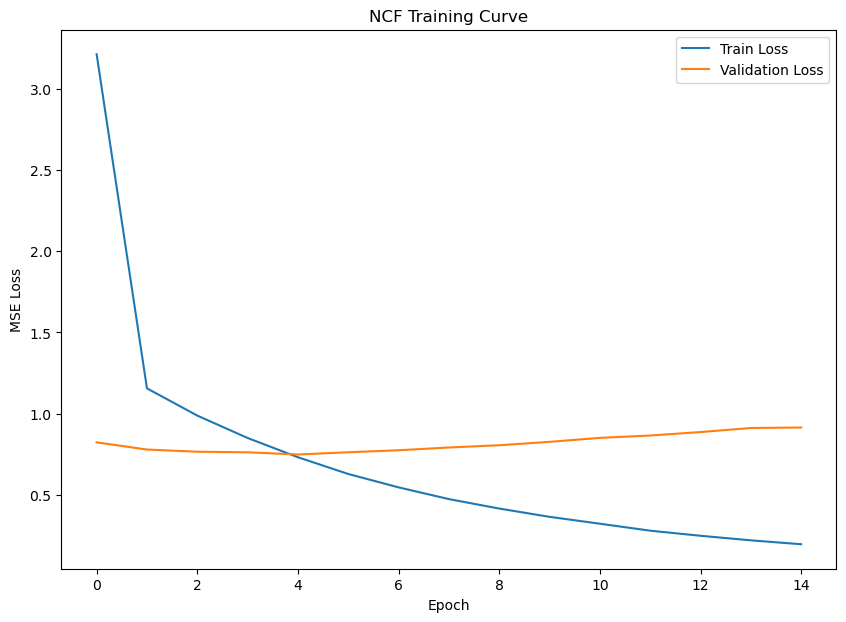

In [59]:
plt.figure(figsize=(10,7))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('NCF Training Curve')
plt.legend()
plt.show()


## 7. Evaluation on Test Set

We load the **best checkpoint** (lowest validation loss) and evaluate on the
untouched test set using:
- **RMSE** (Root Mean Squared Error)
- **MAE** (Mean Absolute Error)


In [60]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for users, movies, ratings in test_loader:
        users, movies = users.to(DEVICE), movies.to(DEVICE)
        preds = model(users, movies)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(ratings.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

all_preds_clipped = np.clip(all_preds, 0.5, 5.0)

rmse = np.sqrt(np.mean((all_preds_clipped - all_targets) ** 2))
mae = np.mean(np.abs(all_preds_clipped - all_targets))

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")

#ORIGINAL #1
# Test RMSE: 0.8628
# Test MAE:  0.6707

#MLP_LAYERS = [64, 32, 32] #2
# Test RMSE: 0.8575
# Test MAE:  0.6633

#MLP_LAYERS = [64, 32, 32, 16] #2
# Test RMSE: 0.8543
# Test MAE:  0.6587

# #2 with step lr reduction of 4 and 0.1 #3
# Test RMSE: 0.8543
# Test MAE:  0.6587

# #3 with embedding size 40
# Test RMSE: 0.8563
# Test MAE:  0.6606

Test RMSE: 0.8543
Test MAE:  0.6587


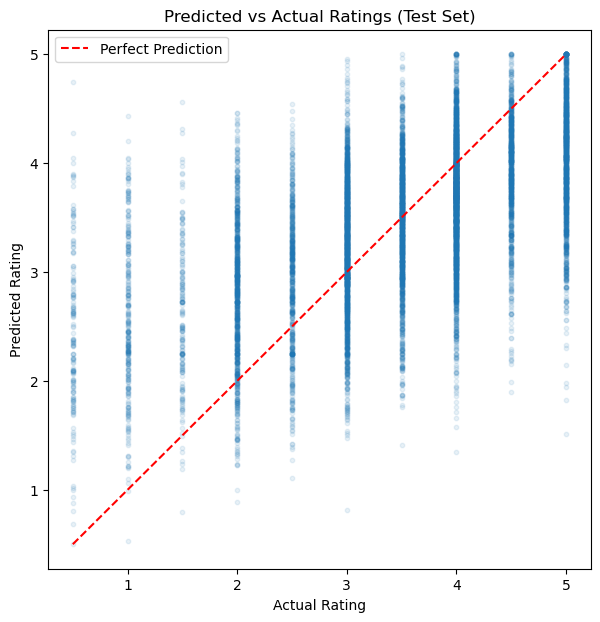

In [61]:
# Visualize: predicted vs actual ratings
plt.figure(figsize=(7,7))
plt.scatter(all_targets, all_preds_clipped, alpha=0.1, s=10)
plt.plot([0.5, 5], [0.5, 5], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Predicted vs Actual Ratings (Test Set)')
plt.legend()
plt.show()


## 8. Save Model for Inference (Dashboard)

We save:
1. The trained model **weights** (`.pt` file)
2. The **model configuration** (architecture hyperparameters) so the dashboard
   can rebuild the exact same architecture before loading the weights
3. A small **inference helper function** to test it works end-to-end


In [62]:
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'ncf_model.pt')
CONFIG_PATH = os.path.join(MODEL_DIR, 'ncf_config.pkl')

torch.save(model.state_dict(), FINAL_MODEL_PATH)

config = {
    'n_users': n_users,
    'n_movies': n_movies,
    'embedding_dim': EMBEDDING_DIM,
    'mlp_layers': MLP_LAYERS,
    'test_rmse': float(rmse),
    'test_mae': float(mae)
}

with open(CONFIG_PATH, 'wb') as f:
    pickle.dump(config, f)

print("Model saved to:", FINAL_MODEL_PATH)
print("Config saved to:", CONFIG_PATH)


Model saved to: models/ncf_model.pt
Config saved to: models/ncf_config.pkl


In [63]:
def predict_for_user(model, user_idx, movie_indices, device):
    model.eval()
    with torch.no_grad():
        user_tensor = torch.tensor([user_idx] * len(movie_indices), dtype=torch.long).to(device)
        movie_tensor = torch.tensor(movie_indices, dtype=torch.long).to(device)
        preds = model(user_tensor, movie_tensor)
        preds = torch.clamp(preds, 0.5, 5.0)
    return preds.cpu().numpy()


sample_user = 0
sample_movies = list(range(5))
sample_preds = predict_for_user(model, sample_user, sample_movies, DEVICE)

for m_idx, pred in zip(sample_movies, sample_preds):
    print(f"User {sample_user} -> Movie idx {m_idx}: predicted rating = {pred:.2f}")


User 0 -> Movie idx 0: predicted rating = 4.79
User 0 -> Movie idx 1: predicted rating = 3.77
User 0 -> Movie idx 2: predicted rating = 4.68
User 0 -> Movie idx 3: predicted rating = 4.80
User 0 -> Movie idx 4: predicted rating = 5.00


In [64]:
def get_top_n_recommendations(model, user_idx, n_movies, watched_movie_indices, device, n=10):
    """
    Predicts ratings for all movies the user hasn't watched yet,
    and returns the indices of the Top-N highest predicted ratings.
    """
    model.eval()
    all_movie_indices = np.arange(n_movies)
    unwatched = np.setdiff1d(all_movie_indices, watched_movie_indices)

    with torch.no_grad():
        user_tensor = torch.tensor([user_idx] * len(unwatched), dtype=torch.long).to(device)
        movie_tensor = torch.tensor(unwatched, dtype=torch.long).to(device)
        preds = model(user_tensor, movie_tensor)
        preds = torch.clamp(preds, 0.5, 5.0).cpu().numpy()

    top_n_idx_in_unwatched = np.argsort(preds)[::-1][:n]
    top_n_movie_indices = unwatched[top_n_idx_in_unwatched]
    top_n_scores = preds[top_n_idx_in_unwatched]

    return list(zip(top_n_movie_indices, top_n_scores))


watched = train_df[train_df['user_idx'] == 0]['movie_idx'].values
recommendations = get_top_n_recommendations(model, user_idx=0, n_movies=n_movies,
                                             watched_movie_indices=watched, device=DEVICE, n=10)

print("Top-10 Recommendations for User idx 0 (movie_idx, predicted_rating):")
for movie_idx, score in recommendations:
    print(f"  Movie idx {movie_idx}: {score:.2f}")


Top-10 Recommendations for User idx 0 (movie_idx, predicted_rating):
  Movie idx 162: 5.00
  Movie idx 108: 5.00
  Movie idx 82: 5.00
  Movie idx 73: 5.00
  Movie idx 238: 5.00
  Movie idx 3162: 5.00
  Movie idx 1278: 5.00
  Movie idx 237: 5.00
  Movie idx 1085: 5.00
  Movie idx 1028: 5.00
